# 01 Dataset exploration

What is actually in the ShiftGuard10 data, and how the test set differs from training.
This was done after the competition. Numbers match `scripts/analyze_dataset.py`.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))
os.environ.setdefault("SG10_DATA_ROOT", os.path.abspath("../data/shift-guard-10-robust-image-classification-challenge"))
ROOT = os.environ["SG10_DATA_ROOT"]
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from PIL import Image
print("data found:", os.path.isdir(ROOT))

data found: True


## Files and class counts

In [2]:
tr = pd.read_csv(os.path.join(ROOT, "train_labels.csv"), dtype=str)
ss = pd.read_csv(os.path.join(ROOT, "sample_submission.csv"), dtype=str)
print("train rows:", len(tr), " test rows:", len(ss))
print("sample_submission labels:", ss.label.value_counts().to_dict())
classes = open(os.path.join(ROOT, "classes.txt")).read().split()
counts = tr.label.value_counts().reindex(classes)
print(counts.to_string())
print("largest / smallest:", counts.max() / counts.min())

train rows: 29400  test rows: 7600
sample_submission labels: {'airplane': 7600}
label
airplane      5000
automobile    5000
bird          5000
cat           5000
deer          4000
dog           4000
frog           500
horse          500
ship           300
truck          100
largest / smallest: 50.0


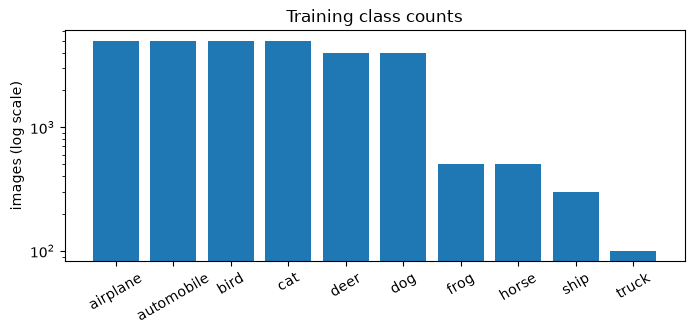

In [3]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(classes, counts.values)
ax.set_yscale("log"); ax.set_ylabel("images (log scale)"); ax.set_title("Training class counts")
plt.xticks(rotation=30); plt.show()

## Load all images

In [4]:
def load(folder, ids):
    return np.stack([np.asarray(Image.open(os.path.join(ROOT, folder, f"{i}.png")).convert("RGB")) for i in ids])
X_tr = load("train_images", tr.id)
X_te = load("test_images", ss.id)
print(X_tr.shape, X_te.shape, X_tr.dtype)

(29400, 32, 32, 3) (7600, 32, 32, 3) uint8


In [ ]:
# Shows competition images. The saved output is removed in the repo (no redistribution); run locally to see it.
fig, axes = plt.subplots(10, 8, figsize=(8, 10))
for r, c in enumerate(classes):
    idx = np.where(tr.label.values == c)[0][:8]
    for k, i in enumerate(idx):
        axes[r, k].imshow(X_tr[i]); axes[r, k].axis("off")
    axes[r, 0].set_title(c, fontsize=8, loc="left")
plt.tight_layout(); plt.show()

## Colour statistics

Train and test have almost the same mean and spread, and both match the CIFAR-10 constants the
code uses for normalisation.

In [6]:
pd.DataFrame({
    "train mean": (X_tr / 255).mean((0, 1, 2)), "test mean": (X_te / 255).mean((0, 1, 2)),
    "CIFAR mean": [0.4914, 0.4822, 0.4465],
    "train std": (X_tr / 255).std((0, 1, 2)), "test std": (X_te / 255).std((0, 1, 2)),
    "CIFAR std": [0.2470, 0.2435, 0.2616]}, index=["R", "G", "B"]).round(4)

,train mean,test mean,CIFAR mean,train std,test std,CIFAR std
R,0.4925,0.4940,0.4914,0.2467,0.2454,0.2470
G,0.4832,0.4841,0.4822,0.2428,0.2413,0.2435
B,0.4474,0.4476,0.4465,0.2614,0.2596,0.2616


## Occlusion patches

Look for solid blocks of RGB (125, 123, 114), the CIFAR mean colour.

In [7]:
import importlib.util
spec = importlib.util.spec_from_file_location("A", os.path.abspath("../scripts/analyze_dataset.py"))
A = importlib.util.module_from_spec(spec); spec.loader.exec_module(A)
p_tr, p_te = A.occlusion_patches(X_tr), A.occlusion_patches(X_te)
print("train:", len(p_tr), "images", f"({100*len(p_tr)/len(X_tr):.2f}%)", "sizes", p_tr.groupby(["h","w"]).size().to_dict())
print("test: ", len(p_te), "images", f"({100*len(p_te)/len(X_te):.2f}%)", "sizes", p_te.groupby(["h","w"]).size().to_dict())

train: 1470 images (5.00%) sizes {(6, 6): 1470}
test:  380 images (5.00%) sizes {(10, 10): 380}


In [ ]:
# Shows competition images. The saved output is removed in the repo (no redistribution); run locally to see it.
fig, axes = plt.subplots(2, 8, figsize=(9, 2.6))
for k in range(8):
    axes[0, k].imshow(X_tr[p_tr.idx.values[k]]); axes[0, k].axis("off")
    axes[1, k].imshow(X_te[p_te.idx.values[k]]); axes[1, k].axis("off")
axes[0, 0].set_title("train: 6x6 patch", fontsize=8, loc="left")
axes[1, 0].set_title("test: 10x10 patch", fontsize=8, loc="left")
plt.tight_layout(); plt.show()

## Colour noise

Noise estimate on the colour-difference channels R-G and B-G. Natural texture mostly cancels
there, added per-pixel noise does not.

In [9]:
c_tr, c_te = A.chroma_noise(X_tr), A.chroma_noise(X_te)
bands = lambda v: pd.Series({"clean (<3.5)": (v < 3.5).mean(), "mild (3.5-6.5)": ((v >= 3.5) & (v < 6.5)).mean(), "strong (>=6.5)": (v >= 6.5).mean()})
pd.DataFrame({"train": bands(c_tr), "test": bands(c_te)}).mul(100).round(1)

,train,test
clean (<3.5),79.1,24.8
mild (3.5-6.5),20.0,36.8
strong (>=6.5),0.9,38.4


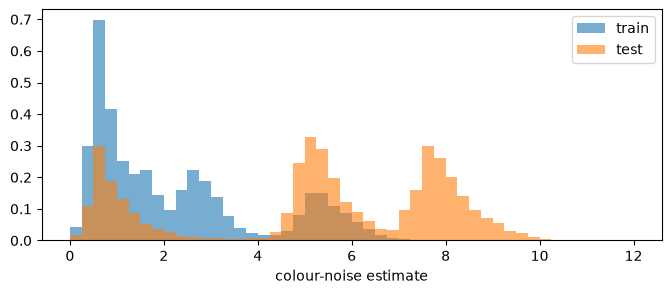

In [10]:
bins = np.linspace(0, 12, 49)
plt.figure(figsize=(8, 3))
plt.hist(c_tr, bins, density=True, alpha=0.6, label="train")
plt.hist(c_te, bins, density=True, alpha=0.6, label="test")
plt.xlabel("colour-noise estimate"); plt.legend(); plt.show()

In [ ]:
# Shows competition images. The saved output is removed in the repo (no redistribution); run locally to see it.
fig, axes = plt.subplots(2, 8, figsize=(9, 2.6))
for k, i in enumerate(np.argsort(-c_tr)[:8]): axes[0, k].imshow(X_tr[i]); axes[0, k].axis("off")
for k, i in enumerate(np.argsort(-c_te)[:8]): axes[1, k].imshow(X_te[i]); axes[1, k].axis("off")
axes[0, 0].set_title("noisiest train", fontsize=8, loc="left"); axes[1, 0].set_title("noisiest test", fontsize=8, loc="left")
plt.tight_layout(); plt.show()

## An earlier model without rebalancing

An earlier notebook trained WRN-28-10 with plain label-smoothed cross-entropy and no class
rebalancing; its saved output shows these predicted test counts (copied from that notebook):

In [12]:
earlier = pd.Series({"dog": 913, "airplane": 857, "horse": 854, "automobile": 850, "deer": 841,
                     "ship": 823, "frog": 715, "cat": 711, "bird": 589, "truck": 447})
pd.DataFrame({"earlier model predictions": earlier, "train share %": (counts / counts.sum() * 100).round(2)})

,earlier model predictions,train share %
airplane,857,17.01
automobile,850,17.01
bird,589,17.01
cat,711,17.01
deer,841,13.61
dog,913,13.61
frog,715,1.70
horse,854,1.70
ship,823,1.02
truck,447,0.34


A model with no rebalancing leans towards the big training classes: it predicted only 447 trucks,
while the stronger models below predict about 950.

## Is the test set balanced? What the strong submissions say

Predicted class counts of three strong submissions from the team repository history. For each class
F1 <= 2 min(predicted, true) / (predicted + true), so these counts cap the possible macro F1.

In [13]:
subs = {"v2 (scored 0.9348)": "../history/submissions/v2_1b98891.csv",
        "v3 2-seed": "../history/submissions/v3_2seed_b90dba0.csv",
        "v3 3-seed (final)": "../submission.csv"}
pred = pd.DataFrame({k: pd.read_csv(v, dtype=str).label.value_counts().reindex(classes) for k, v in subs.items()})
def cap(p, t): return float(np.mean(2 * np.minimum(p, t) / (p + t)))
guesses = {"balanced 760": np.full(10, 760), "training mix": np.round(7600 * counts.values / counts.sum()),
           "500x4, 800x2, 1000x4": np.array([500]*4 + [800]*2 + [1000]*4)}
display(pred)
pd.DataFrame({g: {k: round(cap(pred[k].values, t), 3) for k in pred} for g, t in guesses.items()})

,v2 (scored 0.9348),v3 2-seed,v3 3-seed (final)
label,,,
airplane,534,524,520
automobile,553,553,537
bird,525,519,510
cat,549,570,554
deer,814,801,805
dog,876,812,818
frog,946,962,972
horse,913,937,932
ship,982,983,979


,balanced 760,training mix,"500x4, 800x2, 1000x4"
v2 (scored 0.9348),0.880,0.485,0.966
v3 2-seed,0.881,0.479,0.974
v3 3-seed (final),0.875,0.476,0.980


A balanced test set would cap all three files below 0.881, but v2 scored 0.9348 and the final
0.9488. The test set is very probably tilted towards the classes that are rare in training.

In [14]:
hashes_tr = {hash(a.tobytes()) for a in X_tr}
print("duplicates in train:", len(X_tr) - len(hashes_tr))
print("test images identical to a train image:", sum(hash(a.tobytes()) in hashes_tr for a in X_te))

duplicates in train: 0
test images identical to a train image: 0
